In [18]:
import numpy as np
import matplotlib.pyplot as plt

import sympy as sp

In [19]:
try:
    import casadi
except:
    !pip install casadi
    import casadi

try:
    import do_mpc
except:
    !pip install do_mpc
    import do_mpc

try:
    import pybounds
except:
    #!pip install pybounds
    !pip install git+https://github.com/vanbreugel-lab/pybounds
    import pybounds

### Import plotting utilities and planar drone locally or from github

In [20]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package , function_name)
            return function
        else:
            return package

planar_drone = import_local_or_github('planar_drone', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')
dynamics_utility = import_local_or_github('dynamics_utility', directory='../Utility')

#### Given the planar drone dynamics

$
\mathbf{\dot{x}} = \mathbf{f}(\mathbf{x},\mathbf{u}) =
\frac{d}{dt}
\begin{bmatrix}
\bbox[yellow]{\theta} \\[0.3em]
\bbox[yellow]{\dot{\theta}} \\[0.3em]
\bbox[yellow]{x} \\[0.3em]
\bbox[yellow]{\dot{x}} \\[0.3em]
\bbox[yellow]{z} \\[0.3em]
\bbox[yellow]{\dot{z}} \\[0.3em]
\bbox[pink]{k}
\end{bmatrix} =
\overset{f_0}{\begin{bmatrix}
\bbox[yellow]{\dot{\theta}} \\[0.3em]
0 \\[0.3em]
\bbox[yellow]{\dot{x}} \\[0.3em]
0 \\[0.3em]
\bbox[yellow]{\dot{z}} \\[0.3em]
-\bbox[lightblue]{g} \\[0.3em]
0
\end{bmatrix}} +
\overset{f_1}{\begin{bmatrix}
0 \\[0.3em]
\bbox[lightblue]{l}\bbox[pink]{k}/\bbox[lightblue]{I_{yy}} \\[0.3em]
0 \\[0.3em]
0 \\[0.3em]
0 \\[0.3em]
0 \\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{j_1} +
\overset{f_2}{\begin{bmatrix}
0 \\[0.3em]
0 \\[0.3em]
0 \\[0.3em]
-\bbox[pink]{k}\bbox[yellow]{\sin\theta}/\bbox[lightblue]{m} \\[0.3em]
0 \\[0.3em]
\bbox[pink]{k}\bbox[yellow]{\cos\theta}/\bbox[lightblue]{m}  \\[0.3em]
0
\end{bmatrix}} \bbox[lightgreen]{j_2}
$

#### Consider the following sensor combinations:

$
\mathbf{y_a} = \mathbf{{h_a}}(\mathbf{{x}}, \mathbf{{u}}) =
\begin{bmatrix}
\bbox[yellow]{\theta} \\[0.3em]
\bbox[yellow]{x} \\[0.3em]
\bbox[yellow]{z} \\[0.3em]
\bbox[pink]{k}
\end{bmatrix}
$

$
\mathbf{y_b} = \mathbf{{h_b}}(\mathbf{{x}}, \mathbf{{u}}) =
\begin{bmatrix}
\bbox[yellow]{\dot{x}}/\bbox[yellow]{z} \\[0.3em]
\bbox[yellow]{\theta} \\[0.3em]
\bbox[pink]{k}
\end{bmatrix}
$

$
\mathbf{y_c} = \mathbf{{h_c}}(\mathbf{{x}}, \mathbf{{u}}) =
\begin{bmatrix}
\bbox[yellow]{\dot{x}}/\bbox[yellow]{z} \\[0.3em]
\bbox[yellow]{\theta} \\[0.3em]
\bbox[yellow]{\dot{\theta}}   \\[0.3em]
\ddot{x} = -\bbox[pink]{k} \sin(\bbox[yellow]{\theta}) \bbox[lightgreen]{j_1} / \bbox[lightblue]{m}  \\[0.3em]
\ddot{z} = -\bbox[lightblue]{g} / \bbox[lightblue]{m} + \bbox[pink]{k} \cos(\bbox[yellow]{\theta}) \bbox[lightgreen]{j_2}/ \bbox[lightblue]{m}
\end{bmatrix}
$

In [21]:
f = planar_drone.F().f
h_a = planar_drone.H('h_gps').h
h_b = planar_drone.H('h_camera_theta_k').h
h_c = planar_drone.H('h_camera_imu').h

### Linearize the dynamics and measurement function

We need linearized dynamics of the form:

$
\mathbf{x_{k+1}} = A\mathbf{x_k} + B\mathbf{u_k}
$

$
\mathbf{y_k} = C\mathbf{x_k} + D\mathbf{u_k}
$

We will do that numerically using the same functions as before.

In [22]:
jacobian_numerical = dynamics_utility.jacobian_numerical
rk4_discretize = dynamics_utility.rk4_discretize

In [23]:
# initial condition for planar drone in hover mode

# x = [theta, thetadot, x, xdot, z, zdot, k]
x0 = np.array([0, 0, 0, 0, 1, 0, 1])
u0 = np.array([0, 0])

In [24]:
def f_discrete(x, u):
    dt = 0.1
    return rk4_discretize(f, x, u, dt)

In [25]:
A, B = jacobian_numerical(f_discrete, x0, u0)

In [26]:
C_a, D_a = jacobian_numerical(h_a, x0, u0)
C_b, D_b = jacobian_numerical(h_b, x0, u0)
C_c, D_c = jacobian_numerical(h_c, x0, u0)

# Exercises

1. Determine the rank of the observability matrix for each measurement option. Which ones are observable?
2. Determine the observability Gramian for each measurement option:
  * Analyze the eigenvalues/eigenvectors to determine the most observable state combinations
  * Analyze the matrix inverse of the Gramian to determien the most observable individual states

3. Do your results agree with your Kalman filter from the prior lesson?  

In [50]:
O_a = np.vstack([C_a, C_a@A, C_a@A@A])
print(A.shape[0])
#numpy can give you rank
print(np.linalg.matrix_rank(O_a))
# adding the first derivative improved the rank by 3... whatever that means

7
7


In [51]:
O_b = np.vstack([C_b, C_b@A, C_b@A@A])
print(np.linalg.matrix_rank(O_b))

4


In [52]:
O_c = np.vstack([C_c, C_c@A, C_c@A@A])
print(np.linalg.matrix_rank(O_c))

4


# Observability Gramian calculation

In [53]:
W_a = O_a.T@O_a
W_b = O_b.T@O_b
W_c = O_c.T@O_c

In [54]:
W_a

array([[3.  , 0.3 , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.3 , 0.05, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 3.  , 0.3 , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.3 , 0.05, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 3.  , 0.3 , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.3 , 0.05, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 3.  ]])

In [56]:
def show_eigs_for_W(W):
  eigvals, eigvecs = np.linalg.eig(W)

  # sort eigenvalues from large to smol
  ixsort = np.argsort(eigvals)[::-1]

  print(np.round(eigvals[ixsort], 2))

  print(np.round(eigvecs[:, ixsort], 2))

In [57]:
show_eigs_for_W(W_a)

[3.03 3.03 3.03 3.   0.02 0.02 0.02]
[[ 0.    0.99  0.    0.    0.   -0.1   0.  ]
 [ 0.    0.1   0.    0.    0.    0.99  0.  ]
 [ 0.99  0.    0.    0.   -0.1   0.    0.  ]
 [ 0.1   0.    0.    0.    0.99  0.    0.  ]
 [ 0.    0.    0.99  0.    0.    0.   -0.1 ]
 [ 0.    0.    0.1   0.    0.    0.    0.99]
 [ 0.    0.    0.    1.    0.    0.    0.  ]]


No zeroes in eigenvalues, meaning that we're "full rank"
If you know the ordering, you can see what values on the eigenvector matrix and see which states are easy to estimate and which ones aren't. I think high positive values are good, so thetadot is easy to estimate(?)

Small eigenvalue = hard to estimate
The pattern here is that the derivate ones are hard to estimate


This makes sense because we can ONLY get access to those states by using derivates of measurements we have, rather than direct measurements... deriving an estimate is magnifying your uncertainty a lot?

It gets hard when you have 3 or 4 states that are contributing to the eigenvalue, it's hard to find out what the fuck is contributing to your estimate

In [ ]:
# remember, if you're not full rank, you're not invertible

In [58]:
def plot_Finv_for_W(W, lam=1e-6):
  Finv = np.linalg.inv(W + lam*np.eye(len(W))) # refer to chernoff inverse in notes
  img = plt.imshow(np.log(Finv), origin='upper') # log scale
  cbar = plt.colorbar(img)
  cbar.set_label('log(min err var)', rotation=270, labelpad=15)

/tmp/ipython-input-4096611992.py:3: RuntimeWarning: divide by zero encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale
/tmp/ipython-input-4096611992.py:3: RuntimeWarning: invalid value encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale


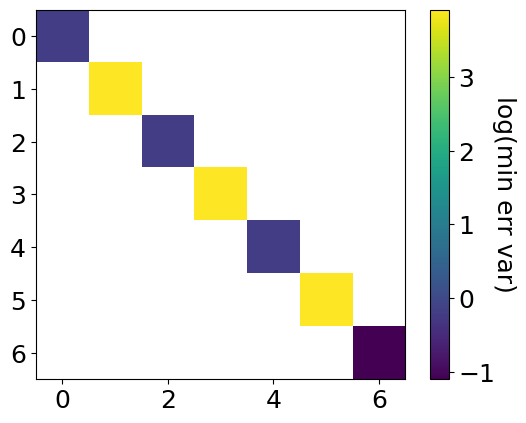

In [63]:
plot_Finv_for_W(W_a)

/tmp/ipython-input-4096611992.py:3: RuntimeWarning: divide by zero encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale
/tmp/ipython-input-4096611992.py:3: RuntimeWarning: invalid value encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale


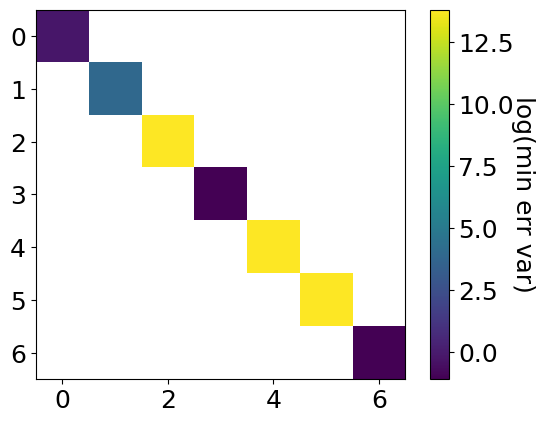

In [64]:
plot_Finv_for_W(W_b)

/tmp/ipython-input-4096611992.py:3: RuntimeWarning: divide by zero encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale
/tmp/ipython-input-4096611992.py:3: RuntimeWarning: invalid value encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale


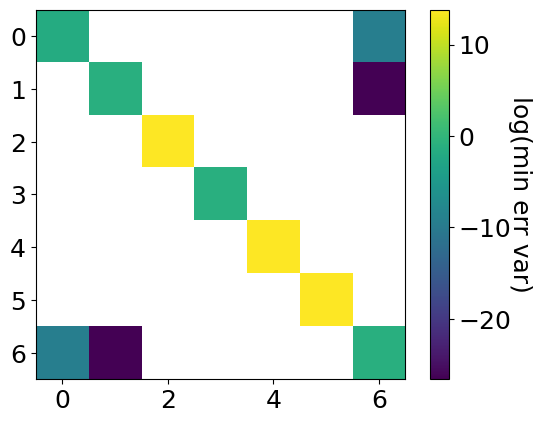

In [62]:
plot_Finv_for_W(W_c)

We can test more powers more efficiently!!! Pythonic language babyyy

/tmp/ipython-input-4096611992.py:3: RuntimeWarning: divide by zero encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale
/tmp/ipython-input-4096611992.py:3: RuntimeWarning: invalid value encountered in log
  img = plt.imshow(np.log(Finv), origin='upper') # log scale


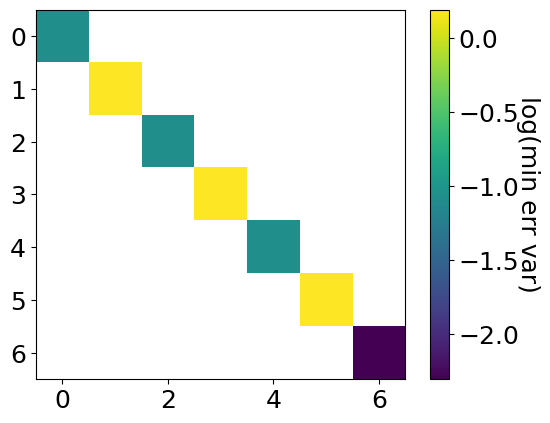

In [66]:
matrix_power = np.linalg.matrix_power

O_a = np.vstack([C_a@matrix_power(A, n) for n in range(10)])
W_a_n = O_a.T@O_a
plot_Finv_for_W(W_a_n)

In [ ]:
# b and c aren't interesting